In [1]:
from InSitu14CO import Site, Firn_Site, Gas, Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

import os.path

from MCEq.core import MCEqRun
from MCEq import config

from tqdm import tqdm

import pandas as pd

import scipy

from scipy import stats

from scipy.io import loadmat
from scipy.interpolate import interp1d

import dynesty

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def bin_average_mat(out_up, out_low, in_low, din):
    S = (out_up-in_low).clip(0,din) - (out_low-in_low).clip(0,din)
    return S/np.sum(S, axis=-1, keepdims=True)

In [4]:
sample_file = 'DomeC 14CO data analysis current.xlsx'
pd_DomeC = pd.read_excel(sample_file, '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])

z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

DC = Firn_Site(
    z_samp = z_exp,
    dz_samp = 20,
    CO = CO_exp,
    CO_err = dCO_exp,
)

In [5]:
L = np.array([1, *np.arange(6.5e-4,7.6e-4,1e-5)]) # Ice Grain Leakage Rates (yr^-1)

In [6]:
grains, leak_open, cumuleak_closed = DC.Calc_14C_ice(L=L)
C14_open, C14_closed, C14_open_atm, C14_closed_atm, c_gases = DC.Calc_profiles(leak_open)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/InSitu14CO.py:591: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/InSitu14CO.py:593: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(Site.lambd+Lrate)[None,None,:]*(Site.age_A+Site.dt_A)[:,None,None]) * np.cumsum(P_A[:,:,None] * np.exp((Site.lambd+Lrate)[None,None,:]*Site.age_A[:,None,None]) * Site.dt_A, axis=0)


0.008459091186523438
interpolating...


100%|███████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  8.00it/s]


integrating...
  Calculated open and closed profiles for gas
11.223785638809204


In [7]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

In [8]:
f = np.array([COS_partition[0,1], 0.06, 0.08])
f

array([0.31125305, 0.06      , 0.08      ])

In [9]:
S_mat = bin_average_mat(DC.z_samp_bins[0,:,None],DC.z_samp_bins[1,:,None],DC.z_grid[None,:],np.array([0,*np.diff(DC.z_grid)])[None,:])

[0.31141798 0.03938045 0.06282092]
chi2 = 25.682907694545648
dof = 12
chi2_red = 2.140242307878804
p = 0.011898461284969164
sig = 2.5151415162053046


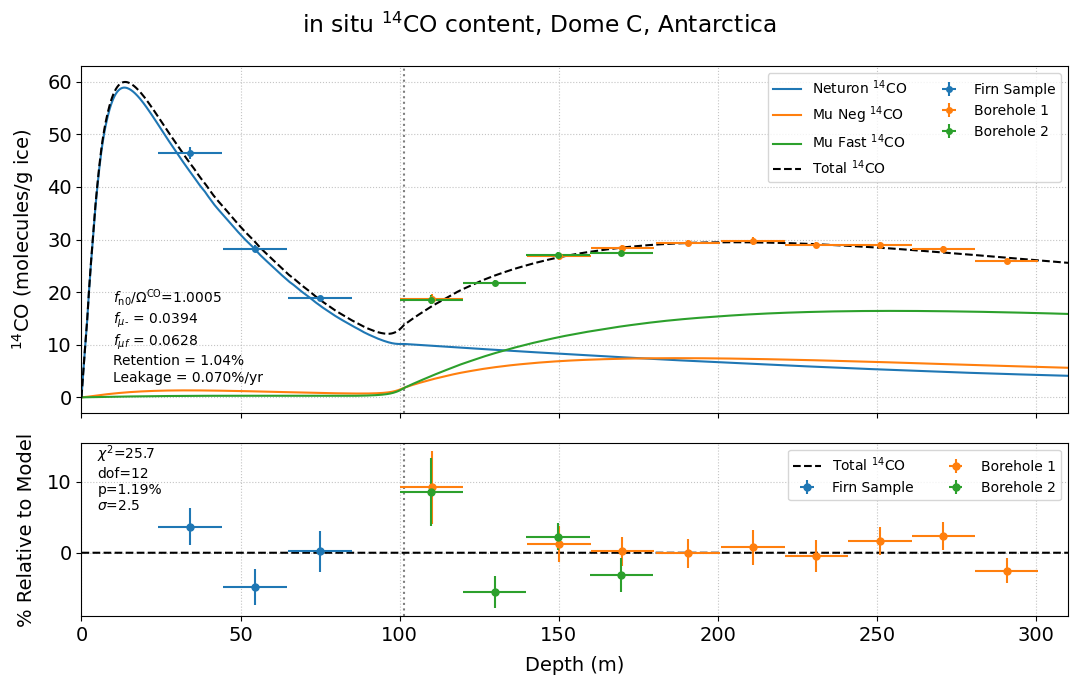

In [15]:
L1 = 7e-4
i_R = np.argmin(abs(L-L1))

R1 = 0.0104
Res = np.zeros(len(L))
Res[0] = 1-R1
Res[i_R] = R1
Res /= np.sum(Res)

#i_avg = np.arange(len(CO_exp))[:,None]
#i_avg = [[0],[1],[2],[3,12],[13],[4,14],[5,15],[6],[7],[8],[9],[10],[11]]
z_exp_avg = z_exp #np.array([np.average(z_exp[i]) for i in i_avg])
CO_exp_avg = CO_exp #np.array([np.average(CO_exp[i]) for i in i_avg])
dCO_exp_avg = dCO_exp #np.array([np.sqrt(np.sum(dCO_exp[i]**2)/len(i)**2+(np.std(CO_exp[i]))**2) for i in i_avg])
Sigma_inv = np.diag(dCO_exp_avg**(-2))

CO_prod_int = S_mat @ ((grains + cumuleak_closed + C14_closed) @ Res)
CO_pi = np.linalg.inv(CO_prod_int.T @ Sigma_inv @ CO_prod_int) @ CO_prod_int.T @ Sigma_inv

f_inv = CO_pi @ CO_exp_avg
print(f_inv)

CO_pred = CO_prod_int @ f_inv

dof = len(CO_exp_avg)-4
chi2 = np.sum((CO_exp_avg-CO_pred)**2/dCO_exp_avg**2)
p = scipy.stats.chi2.sf(chi2, dof)
sig = scipy.stats.norm.isf(p/2)
print('chi2 = {}'.format(chi2))
print('dof = {}'.format(dof))
print('chi2_red = {}'.format(chi2/dof))
print('p = {}'.format(p))
print('sig = {}'.format(sig))

z = DC.z_grid
teller_co = DC.teller_co

fig, axes = plt.subplots(2,1, figsize=(11,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

for ax in axes:
    ax.axvline(z[teller_co], ls=':', c='k', alpha=0.5)
#axes[0].plot(z, f_inv @ (grains + cumuleak_closed + C14_closed) * Res, label=['L={:.1e}/yr'.format(l) if l<1 else 'L=100%/yr' for l in L])
axes[0].plot(z, f_inv * ((grains + cumuleak_closed + C14_closed) @ Res), label=[r'Neturon $^{14}$CO',r'Mu Neg $^{14}$CO',r'Mu Fast $^{14}$CO'])

rel = f_inv @ (grains + cumuleak_closed + C14_closed) @ Res
axes[0].plot(z, f_inv @ (grains + cumuleak_closed + C14_closed) @ Res, c='k', ls='--', label=r'Total $^{14}$CO')
#axes[0].scatter(z_exp, CO_prod_int @ f_inv, c='k')
axes[-1].plot(z, (rel/rel-1)*100, c='k', ls='--', label=r'Total $^{14}$CO')

for ax in axes:
    ax.set_prop_cycle(None)

rel_exp = CO_prod_int @ f_inv
for i in range(len(n_samples)):
    j,k = i_samples[i],i_samples[i+1]
    axes[0].errorbar(z_exp[j:k], CO_exp[j:k], dCO_exp[j:k], xerr=10, fmt='.', markersize=8, label=n_samples[i])
    axes[-1].errorbar(z_exp[j:k], (CO_exp[j:k]/rel_exp[j:k]-1)*100, dCO_exp[j:k]/rel_exp[j:k]*100, xerr=10, fmt='.', markersize=10, label=n_samples[i])

axes[0].set(
    #xlabel='Depth (m)',
    #xlim=(z[0],z[-1]),
    ylabel=r'$^{14}$CO (molecules/g ice)',
    #title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
)
axes[0].legend(fontsize=10, loc='upper right', ncols=2)

axes[-1].set(
    xlabel='Depth (m)',
    xlim=(z[0],z[-1]),
    ylabel='% Relative to Model',
    #title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
)
axes[1].legend(fontsize=10, loc='upper right', ncols=2)

axes[0].text(10,3,r'$f_\text{n0}/\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_inv[0]/COS_partition[0,1])+r'$f_{\mu\text{-}}$ = '+'{:.4f}\n'.format(f_inv[1])+r'$f_{\mu f}$ = '+'{:.4f}\n'.format(f_inv[2])+'Retention = {:.2f}%\nLeakage = {:.3f}%/yr'.format(Res[i_R]*100,L[i_R]*100), fontsize=10)
axes[-1].text(5,6,r'$\chi^2$='+'{:.1f}\n'.format(chi2)+'dof={}\np={:.2f}%\n'.format(dof,p*100)+r'$\sigma$={:.1f}'.format(sig), fontsize=10)

plt.suptitle(r'in situ $^{14}$CO content, Dome C, Antarctica')

plt.show()

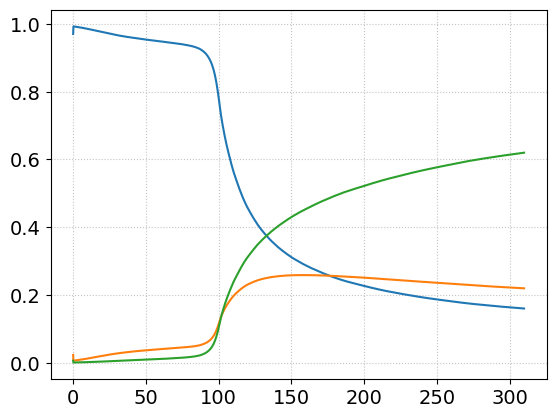

In [160]:
plt.plot(z, f_inv * ((grains + cumuleak_closed + C14_closed) @ Res) / (f_inv @ (grains + cumuleak_closed + C14_closed) @ Res)[:,None])

In [161]:
np.average((f_inv * ((grains + cumuleak_closed + C14_closed) @ Res) / (f_inv @ (grains + cumuleak_closed + C14_closed) @ Res)[:,None])[teller_co:,0])

np.float64(0.2664359271638417)

$$P_{n^0}^{^{14}\text{C}}(h) = N \sigma \Phi_{n^0}(h)$$

$$P^{^{14}\text{C}}_{\mu_f} = N\overline{\sigma}(E)\Phi_{\mu^\pm}(h)$$

$$P^{^{14}\text{CO}} = P^{^{14}\text{C}}\cdot\vec{f}$$
$$\vec{f} = \Omega^{\text{CO}}\vec{\sigma}^*/\vec{\sigma}$$

$$\frac{d}{dt}\,^{14}\text{CO} = \text{Production} - \text{Leak} - \text{Decay}$$